<a href="https://colab.research.google.com/github/ssykes-eth/ETH_273-0003-00L/blob/project/Project_2/recycling_warehouse_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ♻️ Recycling Warehouse: Tile Surface Area Analysis & Batch Approval

Welcome to this project notebook! You will build an end-to-end vision pipeline that automatically **segments intact floor tiles and calculates usable surface area** to determine batch approval — a core task in recycling warehouse operations.

**The Problem**

A batch of reclaimed floor tiles arrives at the warehouse. Photos are taken. Your system must answer two questions:
1. *Where* are the intact (usable) regions? → **Segmentation** (U-Net)
2. *Is there enough usable surface area?* → **Binary Classification** (approve/reject based on 40% threshold)

**Pipeline Overview**

1. 🗂️ **Setup** — Clone repo, configure paths for Colab
2. 🔍 **Dataset** — Load 5000 image–mask pairs, visualize them
3. 🧱 **U-Net** — Train a basic segmentation model
4. 🔢 **FNN Classifier** — Classify from a pooled latent vector
5. 🧠 **CNN Classifier** — Classify from the full spatial latent map
6. ⚖️ **Comparison** — Threshold vs FNN vs CNN: table and metrics
7. 🚀 **Inference** — Walk through the full pipeline on one image
8. 🏆 **Challenge** — Improve the networks to beat the baseline!

**Business Logic:**
- Each batch contains multiple reclaimed floor tiles photographed together
- U-Net segments intact (usable) regions from damaged/unusable areas
- Batches with **>40% intact surface area** → **APPROVE** (sell to customers)
- Batches with **<40% intact surface area** → **REJECT** (send for manual inspection)

By the end you will understand why spatial information in the bottleneck matters for surface area classification, and how two architecturally different heads can exploit the same U-Net backbone in different ways.

---
## 1 🗂️ Setup

Clone the project repository and add it to the Python path so the dataset can be accessed.

In [1]:
# Run this cell once on Colab to clone the repository
!git clone -b week2/warehouse-manager-project https://github.com/eth-bmai-fs26/project.git
%cd project

fatal: destination path 'project' already exists and is not an empty directory.
/content/project


Configure the Python path so that local imports work correctly from the cloned repository.

In [2]:
import os
import sys

# Make sure the repo root is on the Python path so local imports work
PROJECT_ROOT = os.path.abspath(os.getcwd())
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("Working directory:", os.getcwd())

Working directory: /content/project


Import all the libraries we will use throughout this notebook.

In [3]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
from scipy.ndimage import label as scipy_label
import torchvision.transforms as T

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
from week2.project1.utils import (
    dice_loss,
    evaluate_models, plot_accuracy_comparison,
    plot_segmentation_results, plot_inference_result,
    plot_comparison_basic_vs_improved,
    plot_unet_history, plot_classifier_history,
    visualise_samples,
)

Device: cuda


### 1.1 Utility Functions

The following helper function is imported from `week2/project1/utils.py` and used throughout this notebook:

1. **Dice Loss** — A segmentation-specific loss that directly measures overlap between the predicted mask and the ground truth. Unlike Binary Cross-Entropy (which treats every pixel independently), Dice Loss considers the entire region as a whole. This makes it especially useful when the foreground/background class balance is uneven.

   $$\text{Dice} = \frac{2 \cdot |P \cap T|}{|P| + |T|}$$

   We return $1 - \text{Dice}$ so that **lower is better** (standard loss convention).

---
## 2 🔍 Dataset

We have **5000 floor tile batch images**, each paired with a binary segmentation mask that labels the intact (usable) regions.

The files follow this naming convention:

| Original image | Segmentation mask |
|---|---|
| `dataset/original/mosaic_0001.jpg` | `dataset/segmented/mosaic_0001-segmented.jpg` |
| `dataset/original/mosaic_0002.jpg` | `dataset/segmented/mosaic_0002-segmented.jpg` |
| … | … |
| `dataset/original/mosaic_5000.jpg` | `dataset/segmented/mosaic_5000-segmented.jpg` |

`SegmentationDataset` handles this via a `_mask_name()` helper that appends `-segmented` to the original stem. Both images are converted to **grayscale** and resized to **256×256**. Mask pixels above 0.5 are set to 1 (intact region), the rest to 0.

**Dataset composition:**
- **15% pristine batches** — nearly perfect tiles (high approval rate)
- **15% disaster batches** — heavily damaged (high rejection rate)  
- **70% standard batches** — typical mixed quality (where the 40% threshold matters most)

#### 2.1 Dataset Class

`SegmentationDataset` is a custom PyTorch `Dataset` that:
1. Scans the `original/` folder for all `.jpg` images
2. For each image, derives the mask filename by appending `-segmented` (e.g., `mosaic_0001.jpg` → `mosaic_0001-segmented.jpg`)
3. Loads both as **grayscale**, resizes to the target size (256×256)
4. **Binarises** the mask: any pixel above 0.5 becomes 1 (intact), the rest become 0 (damaged)

`LabeledSegmentationDataset` is a thin wrapper that also returns the approval label alongside each `(image, mask)` pair. This is essential after applying `random_split`, because subset indices no longer correspond to the original dataset order.

In [4]:
class SegmentationDataset(Dataset):
    """
    PyTorch Dataset for paired (image, mask) segmentation data.

    Expects the following directory layout:
        root/
            original/       ← raw grayscale images
            segmented/      ← binary segmentation masks (suffix: -segmented)

    Each image is converted to grayscale, resized, and normalised to [0, 1].
    Masks are binarised at 0.5: pixels above → 1 (intact), below → 0 (damaged).
    """

    def __init__(self, root, image_size=(256, 256)):
        self.root = root
        self.image_size = image_size
        self.images = sorted(os.listdir(os.path.join(root, "original")))
        self.transform = T.Compose([
            T.Resize(image_size),
            T.ToTensor(),
        ])

    @staticmethod
    def _mask_name(img_name):
        """Derive the mask filename from the image filename.

        Example: 'mosaic_0001.jpg' → 'mosaic_0001-segmented.jpg'
        """
        stem, ext = os.path.splitext(img_name)
        return f"{stem}-segmented{ext}"

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        mask_name = self._mask_name(img_name)

        # Load as grayscale (L mode) and apply transforms
        img = Image.open(os.path.join(self.root, "original", img_name)).convert("L")
        mask = Image.open(os.path.join(self.root, "segmented", mask_name)).convert("L")

        img = self.transform(img)
        mask = self.transform(mask)

        # Binarise the mask: intact regions → 1, damaged → 0
        mask = (mask > 0.5).float()

        return img, mask


class LabeledSegmentationDataset(Dataset):
    """
    Wraps a SegmentationDataset to also return the approval label.

    This is essential when using random_split: the Subset indices
    no longer match the original dataset order, so we bundle the
    label directly with each sample to avoid index mismatches.

    Returns: (image, mask, label) tuples
        - label = 1 → APPROVE (coverage ≥ 40%)
        - label = 0 → REJECT  (coverage < 40%)
    """

    def __init__(self, base_dataset, labels):
        self.base_dataset = base_dataset
        self.labels = labels

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        img, mask = self.base_dataset[idx]
        label = self.labels[idx]
        return img, mask, label

#### 2.2 Load Data & Split

Load the ground-truth labels from the CSV, build the labelled dataset, and split into **train / validation / test** sets (70 / 15 / 15).

In [5]:
DATA_ROOT = "week2/project1/dataset"

# ── 1. Load ground-truth labels from CSV ──────────────────────────────
ground_truth = pd.read_csv(f"{DATA_ROOT}/ground_truth.csv")
approval_labels = (ground_truth["status"] == "APPROVE").astype(int).tolist()

# ── 2. Build the labelled dataset ─────────────────────────────────────
ds_base = SegmentationDataset(DATA_ROOT, image_size=(256, 256))
ds_full = LabeledSegmentationDataset(ds_base, approval_labels)

# ── 3. Train / Validation / Test split (70 / 15 / 15) ────────────────
train_size = int(0.70 * len(ds_full))
val_size   = int(0.15 * len(ds_full))
test_size  = len(ds_full) - train_size - val_size

torch.manual_seed(42)                      # reproducibility
ds_train, ds_val, ds_test = random_split(ds_full, [train_size, val_size, test_size])

# ── 4. DataLoaders (each batch → (images, masks, labels)) ────────────
dl_train = DataLoader(ds_train, batch_size=32, shuffle=True)
dl_val   = DataLoader(ds_val,   batch_size=32, shuffle=False)
dl_test  = DataLoader(ds_test,  batch_size=32, shuffle=False)

print(f"Total dataset size: {len(ds_full):,} samples")
print(f"  Training set:     {len(ds_train):,} samples (70%)")
print(f"  Validation set:   {len(ds_val):,} samples (15%)")
print(f"  Test set:         {len(ds_test):,} samples (15%)")
print(f"\nEach batch yields: (images, masks, labels)")
print(f"  Image shape: {ds_base[0][0].shape}   (C, H, W)")
print(f"  Mask  shape: {ds_base[0][1].shape}   (C, H, W)")

Total dataset size: 5,000 samples
  Training set:     3,500 samples (70%)
  Validation set:   750 samples (15%)
  Test set:         750 samples (15%)

Each batch yields: (images, masks, labels)
  Image shape: torch.Size([1, 256, 256])   (C, H, W)
  Mask  shape: torch.Size([1, 256, 256])   (C, H, W)


#### 2.3 Visualise Samples

Let's visualise a few samples from the test set to verify the dataset was loaded correctly and the masks look reasonable.

Total samples: 5000
Approved batches: 2725 (54.5%)
Rejected batches: 2275 (45.5%)


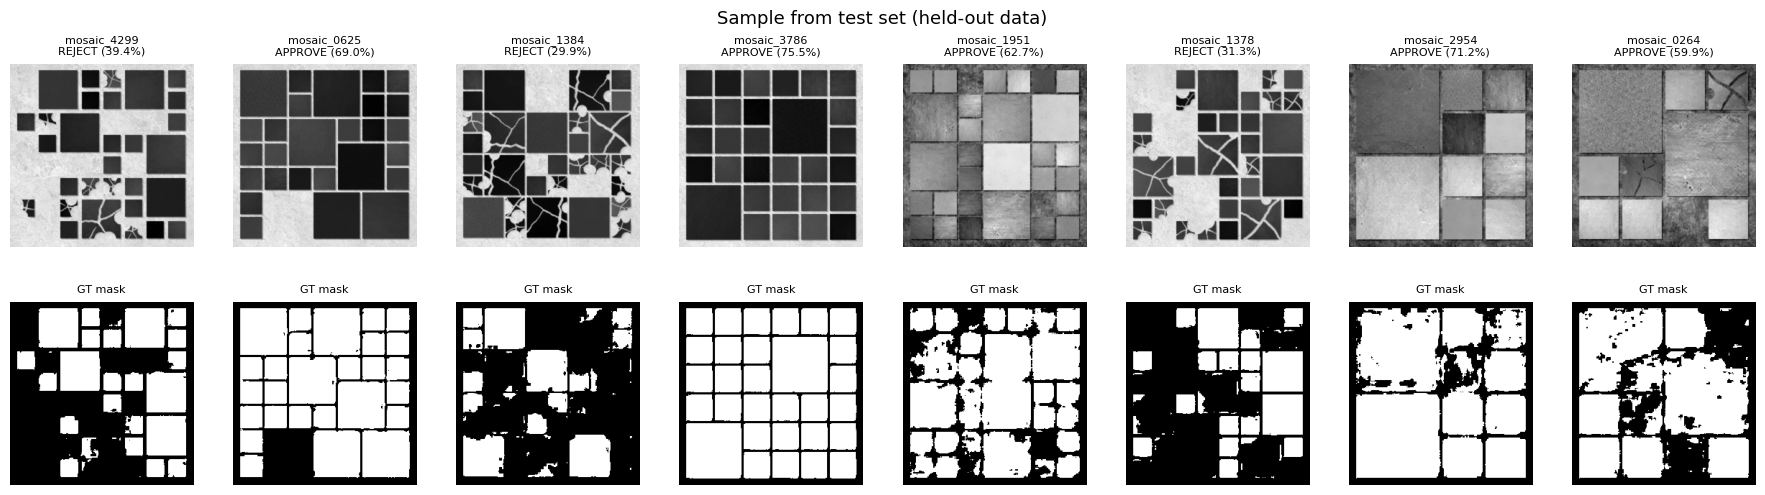

In [6]:
visualise_samples(approval_labels, ds_full, ds_test, ground_truth)

#### What to look for

- Each mask should show **white regions** (value 1) over the intact/usable tiles and **black** (value 0) over damaged/unusable areas.
- **APPROVE** batches should have >40% white pixels (intact coverage)
- **REJECT** batches should have <40% white pixels
- These 8 samples are from the **test set** (held-out data not used for training)

---
## 3 🧱 U-Net Segmentation Model

We start with a simple encoder-decoder model. The encoder compresses the input image into a compact bottleneck representation, and the decoder reconstructs a segmentation mask from it.

**Architecture (`base_ch = 8`, input `256×256`)**

| Stage | Module | Output shape |
|---|---|---|
| Input | — | (B, 1, 256, 256) |
| Encoder block 1 | `Conv2d(1 → 8) + ReLU` | (B, 8, 256, 256) |
| Downsample 1 | `Conv2d stride 2` | (B, 8, 128, 128) |
| Encoder block 2 | `Conv2d(8 → 16) + ReLU` | (B, 16, 128, 128) |
| Downsample 2 | `Conv2d stride 2` | (B, 16, 64, 64) |
| **Bottleneck** | `Conv2d(16 → 16) + ReLU` | **(B, 16, 64, 64)** |
| Upsample 1 | `ConvTranspose2d` | (B, 8, 128, 128) |
| Decoder block 1 | `Conv2d(8 → 8) + ReLU` | (B, 8, 128, 128) |
| Upsample 2 | `ConvTranspose2d` | (B, 8, 256, 256) |
| Decoder block 2 | `Conv2d(8 → 8) + ReLU` | (B, 8, 256, 256) |
| Output | `Conv2d(8 → 1)` | (B, 1, 256, 256) |

The **bottleneck** is the key representation layer. Two methods expose it:
- `get_latent(x)` → GAP → vector **(B, 16)**
- `get_latent_map(x)` → raw spatial map **(B, 16, 64, 64)**

#### 3.1 Architecture Definition

In [7]:
class SimpleConvBlock(nn.Module):
    """Convolution block: Conv → ReLU"""

    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class SimpleUNet(nn.Module):
    """
    Simple encoder-decoder for semantic segmentation.

    Encoder compresses the input, bottleneck holds the latent representation,
    and decoder reconstructs the segmentation mask.
    """

    def __init__(self, in_ch=1, base_ch=8):
        super().__init__()
        self.latent_dim = base_ch * 2  # 16 channels at bottleneck

        # ── Encoder ───────────────────────────────────────────────────
        self.enc1 = SimpleConvBlock(in_ch, base_ch)
        self.down1 = nn.Conv2d(base_ch, base_ch, 4, 2, 1)

        self.enc2 = SimpleConvBlock(base_ch, base_ch * 2)
        self.down2 = nn.Conv2d(base_ch * 2, base_ch * 2, 4, 2, 1)

        # ── Bottleneck ────────────────────────────────────────────────
        self.bottleneck = SimpleConvBlock(base_ch * 2, base_ch * 2)

        # ── Decoder  ─────────────────────────────
        self.up1 = nn.ConvTranspose2d(base_ch * 2, base_ch, 4, 2, 1)
        self.dec1 = SimpleConvBlock(base_ch, base_ch)
        # ── Decoder ──────────────────────────────────────────────────
        self.up2 = nn.ConvTranspose2d(base_ch, base_ch, 4, 2, 1)
        self.dec2 = SimpleConvBlock(base_ch, base_ch)

        # ── Output head ──────────────────────────────────────────────
        self.out_conv = nn.Conv2d(base_ch, 1, 1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        d1 = self.down1(e1)
        e2 = self.enc2(d1)
        d2 = self.down2(e2)

        # Bottleneck
        b = self.bottleneck(d2)

        # Decoder
        u1 = self.up1(b)
        o1 = self.dec1(u1)
        u2 = self.up2(o1)
        o2 = self.dec2(u2)

        return self.out_conv(o2)

    def get_latent(self, x):
        """Returns pooled latent vector (B, 16) via Global Average Pooling."""
        e1 = self.enc1(x)
        d1 = self.down1(e1)

        e2 = self.enc2(d1)
        d2 = self.down2(e2)

        b = self.bottleneck(d2)
        return b.mean(dim=(2, 3))

    def get_latent_map(self, x):
        """Returns spatial bottleneck map (B, 16, 64, 64) without pooling."""
        e1 = self.enc1(x)
        d1 = self.down1(e1)

        e2 = self.enc2(d1)
        d2 = self.down2(e2)

        return self.bottleneck(d2)

Instantiate the model and verify the architecture summary.

In [8]:
unet = SimpleUNet(in_ch=1, base_ch=8)
print(unet)
print(f"\nBottleneck channels (latent_dim): {unet.latent_dim}")

SimpleUNet(
  (enc1): SimpleConvBlock(
    (block): Sequential(
      (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
    )
  )
  (down1): Conv2d(8, 8, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (enc2): SimpleConvBlock(
    (block): Sequential(
      (0): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
    )
  )
  (down2): Conv2d(16, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (bottleneck): SimpleConvBlock(
    (block): Sequential(
      (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
    )
  )
  (up1): ConvTranspose2d(16, 8, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (dec1): SimpleConvBlock(
    (block): Sequential(
      (0): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
    )
  )
  (up2): ConvTranspose2d(8, 8, kernel_size=(4, 4), stride=(2, 2), padding=(1

#### 3.2 Training the U-Net

We train the segmentation model using **Binary Cross-Entropy (BCE)** loss with **SGD** as the optimiser.

> **Note:** The `label` from each batch is ignored during U-Net training — segmentation only needs `(image, mask)` pairs. The label will be used later for classifier training.

In [9]:
def train_unet(model, dataloader, epochs=10, lr=1e-3):
    """
    Train the U-Net segmentation model.
    """
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)

    bce = nn.BCEWithLogitsLoss()
    # optimizer = torch.optim.SGD(model.parameters(), lr=lr) THIS GIVES 50% ACCURACY
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)  # was SGD lr=1e-2 THIS GIVES 90%

    for ep in range(epochs):
        model.train()
        epoch_loss = 0.0

        for img, mask, _label in dataloader:
            img  = img.to(device)
            mask = mask.to(device)

            pred = model(img)
            loss = bce(pred, mask)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg = epoch_loss / len(dataloader)
        print(f"[U-Net] Epoch {ep:3d}/{epochs} | Loss: {avg:.4f}")

# Train the U-Net
train_unet(unet, dl_train, epochs=10, lr=1e-2)

[U-Net] Epoch   0/10 | Loss: 0.6475
[U-Net] Epoch   1/10 | Loss: 0.5699
[U-Net] Epoch   2/10 | Loss: 0.5083
[U-Net] Epoch   3/10 | Loss: 0.4655
[U-Net] Epoch   4/10 | Loss: 0.3802
[U-Net] Epoch   5/10 | Loss: 0.2353
[U-Net] Epoch   6/10 | Loss: 0.1759
[U-Net] Epoch   7/10 | Loss: 0.1438
[U-Net] Epoch   8/10 | Loss: 0.1234
[U-Net] Epoch   9/10 | Loss: 0.2828


#### What to look for

- Loss should decrease over training epochs
- Examine the predicted masks below — how well does the model capture the tile boundaries?
- Pay attention to the quality of the segmentation — are the masks sharp or blurry? Are regions correctly identified?

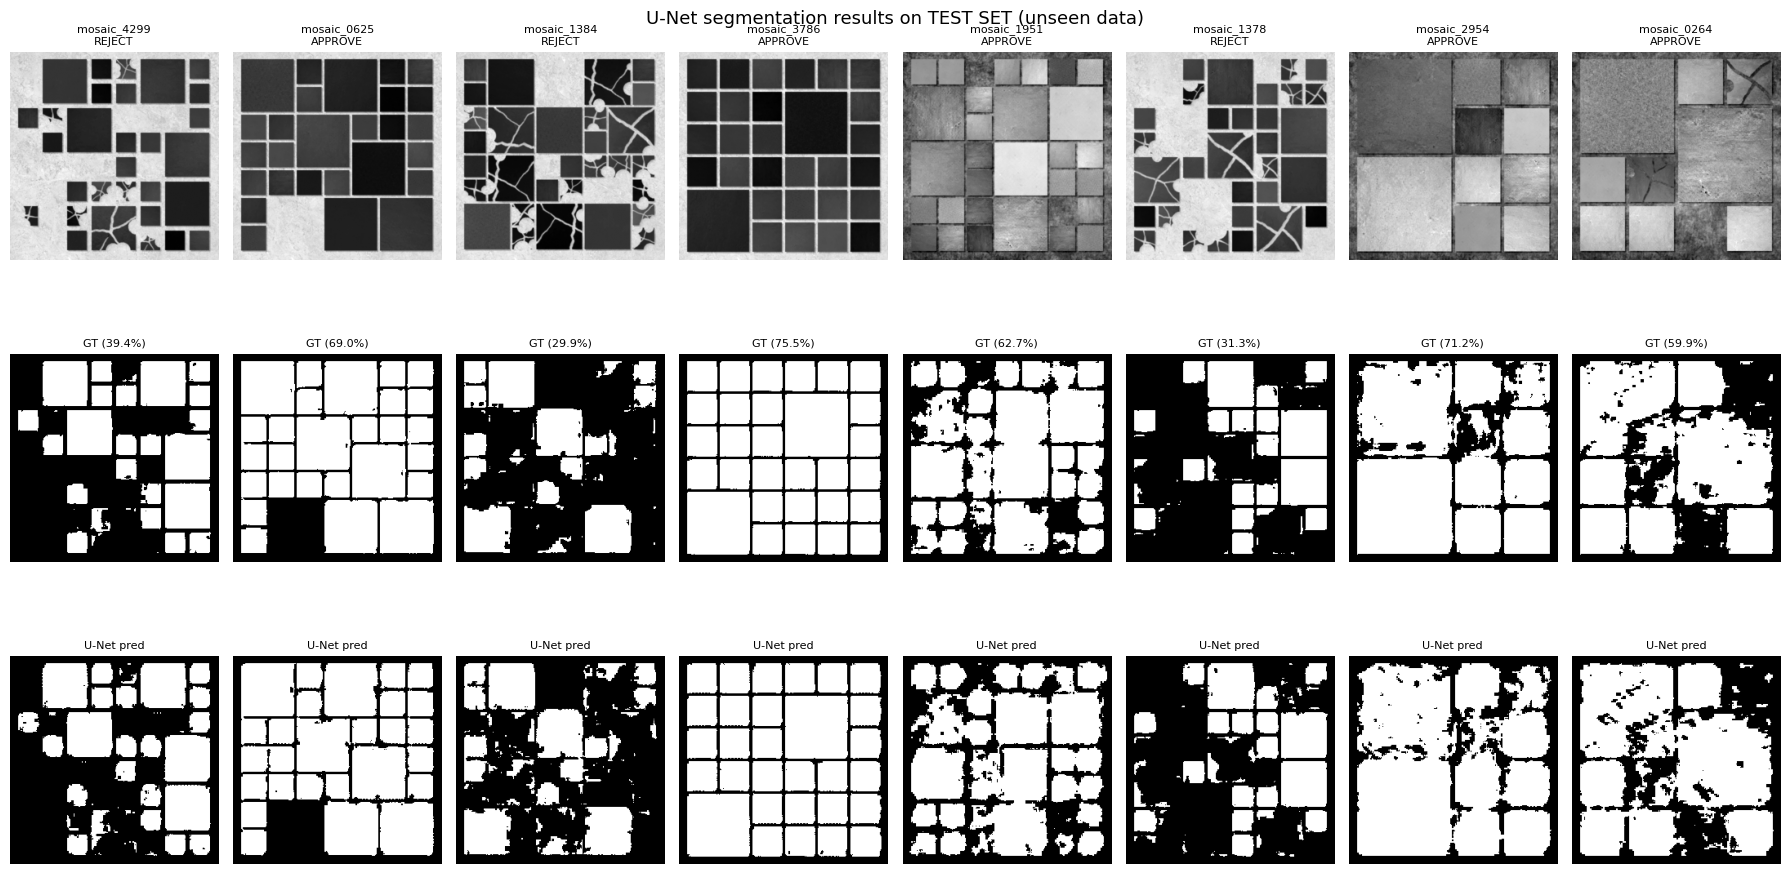

In [10]:
plot_segmentation_results(
    unet, ds_full, ds_test, ground_truth,
    title="U-Net segmentation results on TEST SET (unseen data)",
)


---
## 4 🔢 FNN Classifier — Pooled Latent Vector

The first classification approach collapses the bottleneck into a single vector via **Global Average Pooling** and feeds it to a feedforward network.

```
Bottleneck map (B, 16, 64, 64)
        ↓  Global Average Pooling  [inside SimpleUNet.get_latent()]
   Latent vector (B, 16)
        ↓  Linear(16 → 1) + Sigmoid
   Approval probability p ∈ [0, 1]
```

**Architecture:**

| Layer | Input shape | Output shape |
|---|---|---|
| `Linear(16 → 1)` + Sigmoid | (B, 16) | (B,) → probability in [0, 1] |

#### 4.1 Architecture & Training

In [11]:
class SimpleApprovalFNN(nn.Module):
    """
    Feedforward classifier on the pooled latent vector.
    Maps the latent representation to an approval probability.
    """

    def __init__(self, latent_dim=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 1),
            nn.Sigmoid(),
        )

    def forward(self, z):
        return self.net(z).squeeze(-1)   # (B,) probabilities

Define the training loop for the FNN classifier. The U-Net backbone is frozen — only the classifier weights are updated.

A frozen model or layer has its parameters (weights and biases) locked, preventing them from updating during training. This technique, common in transfer learning, allows us to retain valuable features learned on large datasets while only fine-tuning specific layers to adapt to a new task.

Why We Freeze Models:
- **Prevent Overfitting**: By keeping early layers locked, you avoid overfitting, particularly when training on a small dataset.

- **Save Computation**: Freezing skips backpropagation for certain layers, significantly reducing training time and memory usage.

- **Preserve Learned Features**: Pre-trained models already understand basic patterns (e.g., edges, textures), which are useful across many tasks.

This is done by using `torch.no_grad()` to disable the gradient tape and `unet.eval()` to lock layer-specific behaviors.


In [12]:
def train_classifier_fnn(unet, classifier, dataloader, epochs=10, lr=1e-3):
    """
    Train the FNN approval classifier.
    The U-Net is frozen: we only train the classifier head.
    """
    device = "cuda" if torch.cuda.is_available() else "cpu"
    unet.eval()
    classifier.to(device)

    criterion = nn.BCELoss()
    optimizer = torch.optim.SGD(classifier.parameters(), lr=lr)

    for ep in range(epochs):
        total_loss = 0.0
        for imgs, _masks, labels in dataloader:
            imgs   = imgs.to(device)
            labels = labels.float().to(device)

            with torch.no_grad():
                z = unet.get_latent(imgs)

            pred = classifier(z)
            loss = criterion(pred, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg = total_loss / len(dataloader)
        print(f"[FNN] Epoch {ep:3d}/{epochs} | Loss: {avg:.4f}")

Instantiate the FNN classifier and train it on the latent vectors extracted from the frozen U-Net.

In [13]:
classifier_fnn = SimpleApprovalFNN(latent_dim=unet.latent_dim)
train_classifier_fnn(unet, classifier_fnn, dl_train, epochs=10, lr=1e-2)

[FNN] Epoch   0/10 | Loss: 0.6968
[FNN] Epoch   1/10 | Loss: 0.6561
[FNN] Epoch   2/10 | Loss: 0.6424
[FNN] Epoch   3/10 | Loss: 0.6326
[FNN] Epoch   4/10 | Loss: 0.6287
[FNN] Epoch   5/10 | Loss: 0.6191
[FNN] Epoch   6/10 | Loss: 0.6198
[FNN] Epoch   7/10 | Loss: 0.6150
[FNN] Epoch   8/10 | Loss: 0.6096
[FNN] Epoch   9/10 | Loss: 0.6055


---
## 5 🧠 CNN Classifier — Spatial Latent Map

The second approach skips the early pooling step. Instead of a 16-dimensional vector, the classifier receives the **full spatial feature map** `(B, 16, 64, 64)` and processes it with a convolutional layer before aggregation.

**Architecture:**

| Layer | Input shape | Output shape | Purpose |
|---|---|---|---|
| `Conv2d(16→4, 3×3, pad=1)` + ReLU | (B,16,64,64) | (B,4,64,64) | Spatial processing |
| `AdaptiveAvgPool2d(1)` | (B,4,64,64) | (B,4,1,1) | Global aggregate |
| `Flatten` → `Linear(4→1)` → `Sigmoid` | (B,4) | (B,) | Probability |

#### 5.1 Architecture & Training

In [14]:
class SimpleApprovalCNN(nn.Module):
    """
    Convolutional classifier on the spatial latent map.
    Processes the bottleneck feature map before aggregation.
    """

    def __init__(self, in_channels=16):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 4, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(4, 1),
            nn.Sigmoid(),
        )

    def forward(self, z_map):
        x = self.features(z_map)
        return self.classifier(x).squeeze(-1)

Define the training loop for the CNN classifier. Again, the U-Net is frozen — we only optimise the CNN head.

In [15]:
def train_classifier_cnn(unet, classifier, dataloader, epochs=10, lr=1e-3):
    """
    Train the CNN approval classifier.
    The U-Net is frozen: we only train the classifier head.
    """
    device = "cuda" if torch.cuda.is_available() else "cpu"
    unet.eval()
    classifier.to(device)

    criterion = nn.BCELoss()
    optimizer = torch.optim.SGD(classifier.parameters(), lr=lr)

    for ep in range(epochs):
        total_loss = 0.0
        for imgs, _masks, labels in dataloader:
            imgs   = imgs.to(device)
            labels = labels.float().to(device)

            with torch.no_grad():
                z_map = unet.get_latent_map(imgs)

            pred = classifier(z_map)
            loss = criterion(pred, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg = total_loss / len(dataloader)
        print(f"[CNN] Epoch {ep:3d}/{epochs} | Loss: {avg:.4f}")

Instantiate the CNN classifier and train it on the spatial latent maps from the frozen U-Net.

In [16]:
classifier_cnn = SimpleApprovalCNN(in_channels=unet.latent_dim)
train_classifier_cnn(unet, classifier_cnn, dl_train, epochs=10, lr=1e-2)

[CNN] Epoch   0/10 | Loss: 0.6657
[CNN] Epoch   1/10 | Loss: 0.6239
[CNN] Epoch   2/10 | Loss: 0.5997
[CNN] Epoch   3/10 | Loss: 0.5738
[CNN] Epoch   4/10 | Loss: 0.5468
[CNN] Epoch   5/10 | Loss: 0.5241
[CNN] Epoch   6/10 | Loss: 0.4988
[CNN] Epoch   7/10 | Loss: 0.4804
[CNN] Epoch   8/10 | Loss: 0.4643
[CNN] Epoch   9/10 | Loss: 0.4483


---
## 6 ⚖️ Comparison: FNN vs CNN Classifier

We now evaluate both classifiers on the **TEST SET** (held-out data) and compare their predictions against the ground truth. We also include a **direct threshold** baseline that calculates coverage from the U-Net segmentation mask (if >40% white pixels → APPROVE).

Run the evaluation on the test set and display the first 20 predictions.

In [17]:
df_basic, acc_basic = evaluate_models(
    unet, classifier_fnn, classifier_cnn,
    ds_full, ds_test, ground_truth,
    model_label="BASIC MODELS"
)

print("\nFirst 20 predictions:")
df_basic.head(20).set_index("Image")



BASIC MODELS — Evaluating on 750 test samples (unseen during training)
  Threshold (40% coverage): 95.6% (717/750 correct)
  FNN classifier:           59.6% (447/750 correct)
  CNN classifier:           78.3% (587/750 correct)

First 20 predictions:


,Coverage,Actual,Threshold,FNN pred,CNN pred
Image,,,,,
mosaic_4299,39.4%,REJECT,REJECT,REJECT,REJECT
mosaic_0625,69.0%,APPROVE,APPROVE,APPROVE,APPROVE
mosaic_1384,29.9%,REJECT,REJECT,APPROVE,REJECT
mosaic_3786,75.5%,APPROVE,APPROVE,APPROVE,APPROVE
mosaic_1951,62.7%,APPROVE,APPROVE,REJECT,APPROVE
mosaic_1378,31.3%,REJECT,REJECT,REJECT,REJECT
mosaic_2954,71.2%,APPROVE,APPROVE,REJECT,APPROVE
mosaic_0264,59.9%,APPROVE,APPROVE,REJECT,REJECT
mosaic_1266,29.8%,REJECT,REJECT,APPROVE,REJECT


Plot the accuracy comparison for the basic models.

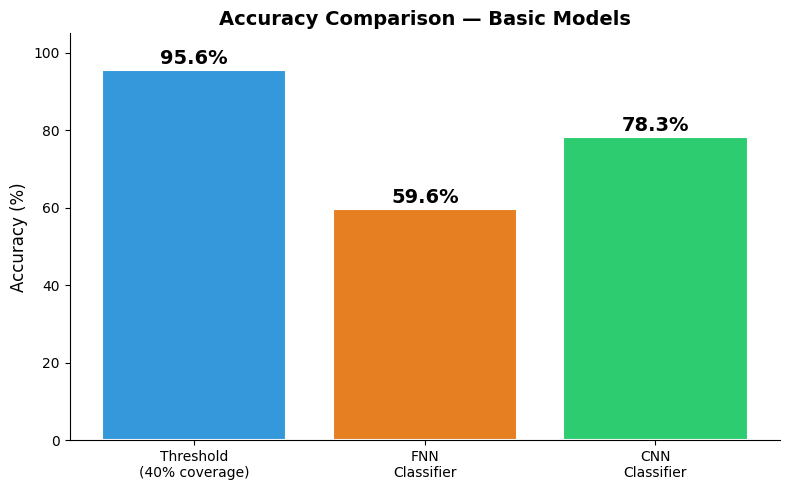

In [18]:
plot_accuracy_comparison(acc_basic, title="Accuracy Comparison — Basic Models")


#### Interpreting the comparison

| Method | What it sees | Inductive bias |
|---|---|---|
| **Threshold (40%)** | Predicted segmentation mask | Rule-based: count white pixels, apply 40% cutoff |
| **FNN classifier** | Pooled latent vector | Learns from a compressed summary of the bottleneck |
| **CNN classifier** | Spatial latent map | Processes spatial features before aggregating |

Take a close look at the results. Are you satisfied with the accuracy? In Section 8, you will have the opportunity to improve these models and push the accuracy significantly higher.

---
## 7 🚀 Full Pipeline Inference on a Single Image

Let us walk through the entire pipeline on a sample batch from the **test set** near the 40% threshold — the most challenging case where the decision matters most.

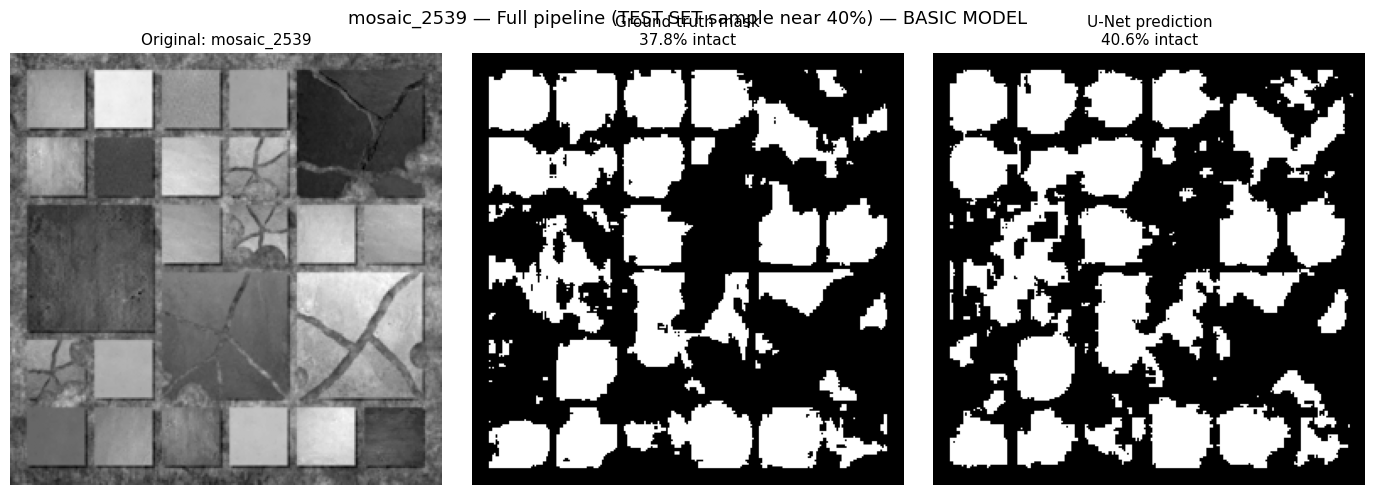

INFERENCE SUMMARY — BASIC MODEL (TEST SET SAMPLE)
Batch:                mosaic_2539
Actual coverage:      37.8%
Actual decision:      REJECT
------------------------------------------------------------
U-Net coverage:       40.6%
Threshold decision:   APPROVE  (>40% → APPROVE)
FNN decision:         APPROVE  (prob=0.532)
CNN decision:         APPROVE  (prob=0.521)


In [19]:
# Find a batch near the 40% threshold from the TEST SET for demonstration
threshold_test_samples = []
for idx in ds_test.indices:
    cov = ground_truth.iloc[idx]["coverage_pct"]
    if 0.35 <= cov <= 0.45:
        threshold_test_samples.append((idx, cov))

# Pick one near the middle
IDX = threshold_test_samples[len(threshold_test_samples)//2][0] if threshold_test_samples else ds_test.indices[0]

img, gt_mask, label = ds_full[IDX]
img_t = img.unsqueeze(0).to(device)

unet.eval(); classifier_fnn.eval(); classifier_cnn.eval()

with torch.no_grad():
    logits   = unet(img_t)
    seg_pred = torch.sigmoid(logits)
    seg_bin  = (seg_pred > 0.5).float()
    coverage = seg_pred.mean().item()
    threshold_decision = "APPROVE" if coverage > 0.4 else "REJECT"

    z        = unet.get_latent(img_t)
    fnn_prob = classifier_fnn(z).item()
    fnn_decision = "APPROVE" if fnn_prob > 0.5 else "REJECT"

    z_map    = unet.get_latent_map(img_t)
    cnn_prob = classifier_cnn(z_map).item()
    cnn_decision = "APPROVE" if cnn_prob > 0.5 else "REJECT"

actual_decision  = "APPROVE" if label == 1 else "REJECT"
actual_coverage  = ground_truth.iloc[IDX]["coverage_pct"]

plot_inference_result(img, gt_mask, seg_bin, IDX, coverage, actual_coverage,
                      title_suffix="BASIC MODEL")

print("=" * 60)
print("INFERENCE SUMMARY — BASIC MODEL (TEST SET SAMPLE)")
print("=" * 60)
print(f"Batch:                mosaic_{IDX+1:04d}")
print(f"Actual coverage:      {actual_coverage*100:.1f}%")
print(f"Actual decision:      {actual_decision}")
print("-" * 60)
print(f"U-Net coverage:       {coverage*100:.1f}%")
print(f"Threshold decision:   {threshold_decision}  (>40% → APPROVE)")
print(f"FNN decision:         {fnn_decision}  (prob={fnn_prob:.3f})")
print(f"CNN decision:         {cnn_decision}  (prob={cnn_prob:.3f})")
print("=" * 60)


---
## 7b 🌐 Interactive Web App — Try Your Trained Model Live

In this section you run the full **Warehouse Inspector** app directly inside this notebook, powered by your trained U-Net.

The approach is identical to `project_task_meeting`:
- Python functions are registered as **Colab callbacks** with `output.register_callback`
- The HTML app calls them via `google.colab.kernel.invokeFunction`; results arrive in `result.data["text/plain"]` and are parsed as JSON
- The self-contained HTML file is loaded from the cloned repo and displayed with `IPython.display.HTML`

**App modes:**
- **Challenge Mode** — look at a tile batch, decide APPROVE or REJECT, then see the model's segmentation mask and verdict
- **Explorer Mode** — drag a slider to compare original image vs U-Net mask for any tile

> **Which model?** Cell 7b.1 uses `unet` (Section 3). Replace with `unet_improved` after Section 8.

### 7b.1  Generate Segmentation Masks

Run the trained U-Net on every image in the dataset and save the results so the app can serve them:
- Binary masks → `dataset/segmented/<name>-segmented.jpg`
- Updated CSV → `dataset/ground_truth.csv` (model-predicted coverage % and APPROVE / REJECT)

In [20]:
import os
import numpy as np
from PIL import Image
import pandas as pd

APP_DATA_ROOT = "week2/project1/dataset"
ORIG_DIR = os.path.join(APP_DATA_ROOT, "original")
SEG_DIR  = os.path.join(APP_DATA_ROOT, "segmented")
os.makedirs(SEG_DIR, exist_ok=True)

model_for_app = unet
model_for_app.eval()
_device    = next(model_for_app.parameters()).device
_transform = T.Compose([T.Resize((256, 256)), T.ToTensor()])

records   = []
filenames = sorted(f for f in os.listdir(ORIG_DIR) if f.lower().endswith(".jpg"))
print(f"Running inference on {len(filenames)} images...")

for i, fname in enumerate(filenames):
    img_pil   = Image.open(os.path.join(ORIG_DIR, fname)).convert("L")
    orig_size = img_pil.size
    img_t     = _transform(img_pil).unsqueeze(0).to(_device)

    with torch.no_grad():
        pred = torch.sigmoid(model_for_app(img_t)).squeeze().cpu().numpy()

    binary_mask   = (pred > 0.5).astype(np.uint8)
    coverage_pct  = float(binary_mask.mean())
    status        = "APPROVE" if coverage_pct >= 0.40 else "REJECT"

    stem = os.path.splitext(fname)[0]
    Image.fromarray(binary_mask * 255).convert("RGB") \
         .resize(orig_size, Image.Resampling.NEAREST) \
         .save(os.path.join(SEG_DIR, f"{stem}-segmented.jpg"))

    records.append({
        "filename":      fname,
        "intact_pixels": int(binary_mask.sum()),
        "coverage_pct":  round(coverage_pct, 4),
        "status":        status,
    })
    if (i + 1) % 500 == 0:
        print(f"  {i+1}/{len(filenames)}")

df_app = pd.DataFrame(records)
df_app.to_csv(os.path.join(APP_DATA_ROOT, "ground_truth.csv"), index=False)
approved = (df_app["status"] == "APPROVE").sum()
print(f"Done: {len(records)} images  →  APPROVE {approved}  |  REJECT {len(records) - approved}")

Running inference on 5000 images...
  500/5000
  1000/5000
  1500/5000
  2000/5000
  2500/5000
  3000/5000
  3500/5000
  4000/5000
  4500/5000
  5000/5000
Done: 5000 images  →  APPROVE 2840  |  REJECT 2160


### 7b.2  Register Callbacks and Launch the App

Exactly like `project_task_meeting`:
1. Register two Python callbacks with `output.register_callback`
   - **`getTiles`** — returns the tile list (filename, coverage %, status) as `json.dumps(...)`
   - **`getImage`** — reads an image from disk, base64-encodes it, returns as `json.dumps(...)`
2. The HTML calls them via `google.colab.kernel.invokeFunction`; the JS reads `result.data["text/plain"]`, strips the surrounding Python string quotes, and calls `JSON.parse`
3. The HTML file (`warehouse_app_colab.html`) is read from the cloned repo and displayed with `IPython.display.HTML`

In [21]:
import base64, json, os
import IPython.display
from google.colab import output

_df   = pd.read_csv(os.path.join(APP_DATA_ROOT, "ground_truth.csv"))
_tiles = [
    {
        "index":        int(i),
        "filename":     row["filename"],
        "coverage_pct": float(row["coverage_pct"]),
        "status":       row["status"],
    }
    for i, row in _df.iterrows()
]

def getTiles():
    return json.dumps(_tiles)

def getImage(filename, image_type):
    if image_type == "original":
        path = os.path.join(ORIG_DIR, filename)
    else:
        stem = os.path.splitext(filename)[0]
        path = os.path.join(SEG_DIR, f"{stem}-segmented.jpg")
    with open(path, "rb") as f:
        b64 = base64.b64encode(f.read()).decode("utf-8")
    return json.dumps({"image": b64})

output.register_callback("getTiles",  getTiles)
output.register_callback("getImage",  getImage)
print("Callbacks registered.")

with open("week2/project1/warehouse_app_colab.html") as f:
    html_app = f.read()

IPython.display.display(IPython.display.HTML(html_app))

Callbacks registered.


---
## 8 🏆 Challenge: Beat the Baseline!

The results from the previous sections show there is significant room for improvement. Your task is to redesign the three networks to achieve substantially better performance.

### Your Task

Improve the three networks — **U-Net**, **FNN classifier**, and **CNN classifier** — to achieve the following target accuracy on the test set:

| Method | Target Accuracy |
|---|---|
| Threshold (40% rule) | **>= 95%** |
| FNN classifier | **>= 93%** |
| CNN classifier | **>= 95%** |

### What you can change

You have full freedom to modify the **model architectures** and **hyperparameters**. Think about what could be limiting the current models and what changes might help. Consider:

- Network depth and width
- Types of layers and their configuration
- Training procedure (optimiser, learning rate, number of epochs)
- Loss functions
- Any architectural patterns from the literature that could help

### What is already provided

You do **not** need to rewrite the training loops or evaluation code. The following are provided:
- `train_unet_improved()` — trains the U-Net with validation tracking (loss curves)
- `train_classifier_improved()` — trains either classifier with validation tracking (loss + accuracy curves)
- `evaluate_models()` — the same evaluation function from Section 6 (imported from utils)
- Plotting cells for training curves to monitor your progress

### Rules
1. You must define three new model classes: `ImprovedUNet`, `ImprovedFNN`, `ImprovedCNN`
2. They must expose the same interface: `forward()`, `get_latent()`, `get_latent_map()` for the U-Net; `forward(z)` for classifiers
3. **Important:** Since the classifiers depend on the U-Net's bottleneck features, you must **retrain all three** after improving the U-Net

Good luck!


### 8.1 Improved Training Loops (provided)

These training functions track **validation metrics** every epoch so you can monitor progress and diagnose overfitting/underfitting as you iterate on your architectures.


In [22]:
def train_unet_improved(model, dl_train, dl_val, epochs=50, lr=1e-3):
    """
    Train U-Net with validation tracking.
    Returns history dict with train_loss and val_loss per epoch.
    """
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)

    bce = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": []}

    for ep in range(epochs):
        model.train()
        train_loss = 0.0
        for img, mask, _label in dl_train:
            img  = img.to(device)
            mask = mask.to(device)
            pred = model(img)
            loss = bce(pred, mask) + dice_loss(pred, mask).mean()
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            train_loss += loss.item()
        train_loss /= len(dl_train)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for img, mask, _label in dl_val:
                img  = img.to(device)
                mask = mask.to(device)
                pred = model(img)
                loss = bce(pred, mask) + dice_loss(pred, mask).mean()
                val_loss += loss.item()
        val_loss /= len(dl_val)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if ep % 5 == 0 or ep == epochs - 1:
            print(f"[U-Net] Epoch {ep:3d}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    return history


def train_classifier_improved(unet, classifier, dl_train, dl_val, mode="fnn", epochs=50, lr=1e-3):
    """
    Train a classifier (FNN or CNN) with validation tracking.
    mode: "fnn" uses get_latent(), "cnn" uses get_latent_map()
    Returns history dict with train_loss, val_loss, val_acc per epoch.
    """
    device = "cuda" if torch.cuda.is_available() else "cpu"
    unet.eval()
    classifier.to(device)

    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(classifier.parameters(), lr=lr)
    get_features = unet.get_latent if mode == "fnn" else unet.get_latent_map

    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    for ep in range(epochs):
        classifier.train()
        train_loss = 0.0
        for imgs, _masks, labels in dl_train:
            imgs   = imgs.to(device)
            labels = labels.float().to(device)
            with torch.no_grad():
                z = get_features(imgs)
            pred = classifier(z)
            loss = criterion(pred, labels)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            train_loss += loss.item()
        train_loss /= len(dl_train)

        classifier.eval()
        val_loss = 0.0; correct = 0; total = 0
        with torch.no_grad():
            for imgs, _masks, labels in dl_val:
                imgs   = imgs.to(device)
                labels = labels.float().to(device)
                z      = get_features(imgs)
                pred   = classifier(z)
                val_loss += criterion(pred, labels).item()
                correct  += ((pred > 0.5).float() == labels).sum().item()
                total    += labels.size(0)
        val_loss /= len(dl_val)
        val_acc   = correct / total * 100

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if ep % 5 == 0 or ep == epochs - 1:
            print(f"[{mode.upper()}] Epoch {ep:3d}/{epochs} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | Acc: {val_acc:.1f}%")

    return history


### 8.2 Improved U-Net

Define your improved U-Net below. Think about what was missing in `SimpleUNet` and what architectural changes could help the model segment tiles more accurately.

> **Hint:** Look at what `SimpleUNet` lacks compared to the classical U-Net architecture.


In [23]:
class ConvBlock(nn.Module):
    """Convolution block: Conv → ReLU

    # TODO: 🎯 Change the structure to improve the performance!
    """

    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class ImprovedUNet(nn.Module):
    """
    # TODO: 🎯 Change the structure to improve the performance!
    # (Hint: Leave unchanged get_latent and get_latent_map)
    # (Hint: Is there something missing in the architecture?)
    """

    def __init__(self, in_ch=1, base_ch=32):
        super().__init__()
        self.latent_dim = base_ch * 2

        # ── Encoder ───────────────────────────────────────────────────
        self.enc1 = ConvBlock(in_ch, base_ch)
        self.down1 = nn.Conv2d(base_ch, base_ch, 4, 2, 1)

        self.enc2 = ConvBlock(base_ch, base_ch * 2)
        self.down2 = nn.Conv2d(base_ch * 2, base_ch * 2, 4, 2, 1)

        # ── Bottleneck ────────────────────────────────────────────────
        self.bottleneck = ConvBlock(base_ch * 2, base_ch * 2)

        # ── Decoder ───────────────────────────
        self.up1 = nn.ConvTranspose2d(base_ch * 2, base_ch * 2, 4, 2, 1)
        self.dec1 = ConvBlock(base_ch * 4, base_ch)   # 128 → 32

        self.up2 = nn.ConvTranspose2d(base_ch, base_ch, 4, 2, 1)
        self.dec2 = ConvBlock(base_ch * 2, base_ch)   # 64 → 32

        # ── Output head ──────────────────────────────────────────────
        self.out_conv = nn.Conv2d(base_ch, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)          # (B, 32, H, W)
        d1 = self.down1(e1)

        e2 = self.enc2(d1)         # (B, 64, H/2, W/2)
        d2 = self.down2(e2)

        b = self.bottleneck(d2)

        u1 = self.up1(b)           # (B, 64, H/2, W/2)
        u1 = torch.cat([u1, e2], dim=1)   # → (B, 128, ...)
        o1 = self.dec1(u1)

        u2 = self.up2(o1)          # (B, 32, H, W)
        u2 = torch.cat([u2, e1], dim=1)   # → (B, 64, ...)
        o2 = self.dec2(u2)

        return self.out_conv(o2)

    def get_latent(self, x):
        """Returns pooled latent vector (B, latent_dim) via Global Average Pooling."""
        e1 = self.enc1(x);  d1 = self.down1(e1)
        e2 = self.enc2(d1); d2 = self.down2(e2)
        b = self.bottleneck(d2)
        return b.mean(dim=(2, 3))

    def get_latent_map(self, x):
        """Returns spatial bottleneck map (B, latent_dim, H', W') without pooling."""
        e1 = self.enc1(x);  d1 = self.down1(e1)
        e2 = self.enc2(d1); d2 = self.down2(e2)
        return self.bottleneck(d2)

Instantiate and inspect your improved U-Net.


In [24]:
unet_improved = ImprovedUNet(in_ch=1, base_ch=32)
print(unet_improved)
print(f"\nBottleneck channels (latent_dim): {unet_improved.latent_dim}")


ImprovedUNet(
  (enc1): ConvBlock(
    (block): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
    )
  )
  (down1): Conv2d(32, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (enc2): ConvBlock(
    (block): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
    )
  )
  (down2): Conv2d(64, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (bottleneck): ConvBlock(
    (block): Sequential(
      (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
    )
  )
  (up1): ConvTranspose2d(64, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (dec1): ConvBlock(
    (block): Sequential(
      (0): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
    )
  )
  (up2): ConvTranspose2d(32, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (dec

Train the improved U-Net with validation tracking.


In [25]:
unet_history = train_unet_improved(unet_improved, dl_train, dl_val, epochs=50, lr=1e-3)


[U-Net] Epoch   0/50 | Train Loss: 0.8985 | Val Loss: 0.5435
[U-Net] Epoch   5/50 | Train Loss: 0.1094 | Val Loss: 0.1169
[U-Net] Epoch  10/50 | Train Loss: 0.0697 | Val Loss: 0.0653
[U-Net] Epoch  15/50 | Train Loss: 0.0565 | Val Loss: 0.0528
[U-Net] Epoch  20/50 | Train Loss: 0.0528 | Val Loss: 0.0704
[U-Net] Epoch  25/50 | Train Loss: 0.0375 | Val Loss: 0.0647
[U-Net] Epoch  30/50 | Train Loss: 0.0335 | Val Loss: 0.0301
[U-Net] Epoch  35/50 | Train Loss: 0.0311 | Val Loss: 0.0345
[U-Net] Epoch  40/50 | Train Loss: 0.0264 | Val Loss: 0.0243
[U-Net] Epoch  45/50 | Train Loss: 0.0269 | Val Loss: 0.0311
[U-Net] Epoch  49/50 | Train Loss: 0.0266 | Val Loss: 0.0243


Plot training and validation loss curves.


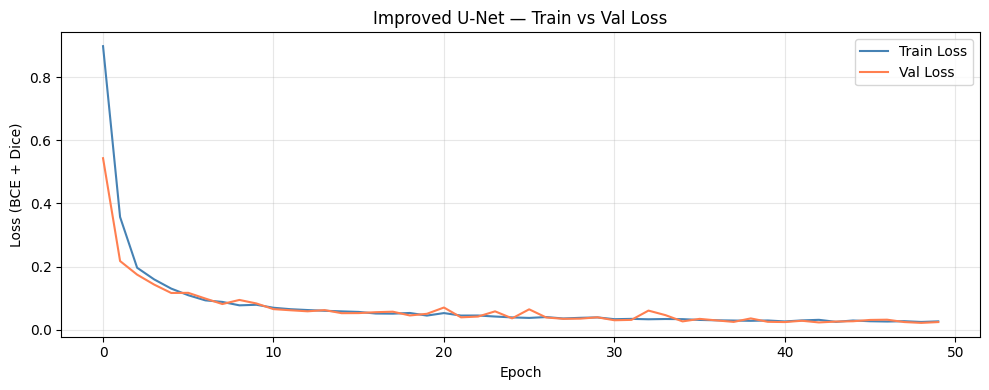

In [26]:
plot_unet_history(unet_history, title="Improved U-Net — Train vs Val Loss")


Visualise segmentation predictions on the test set.


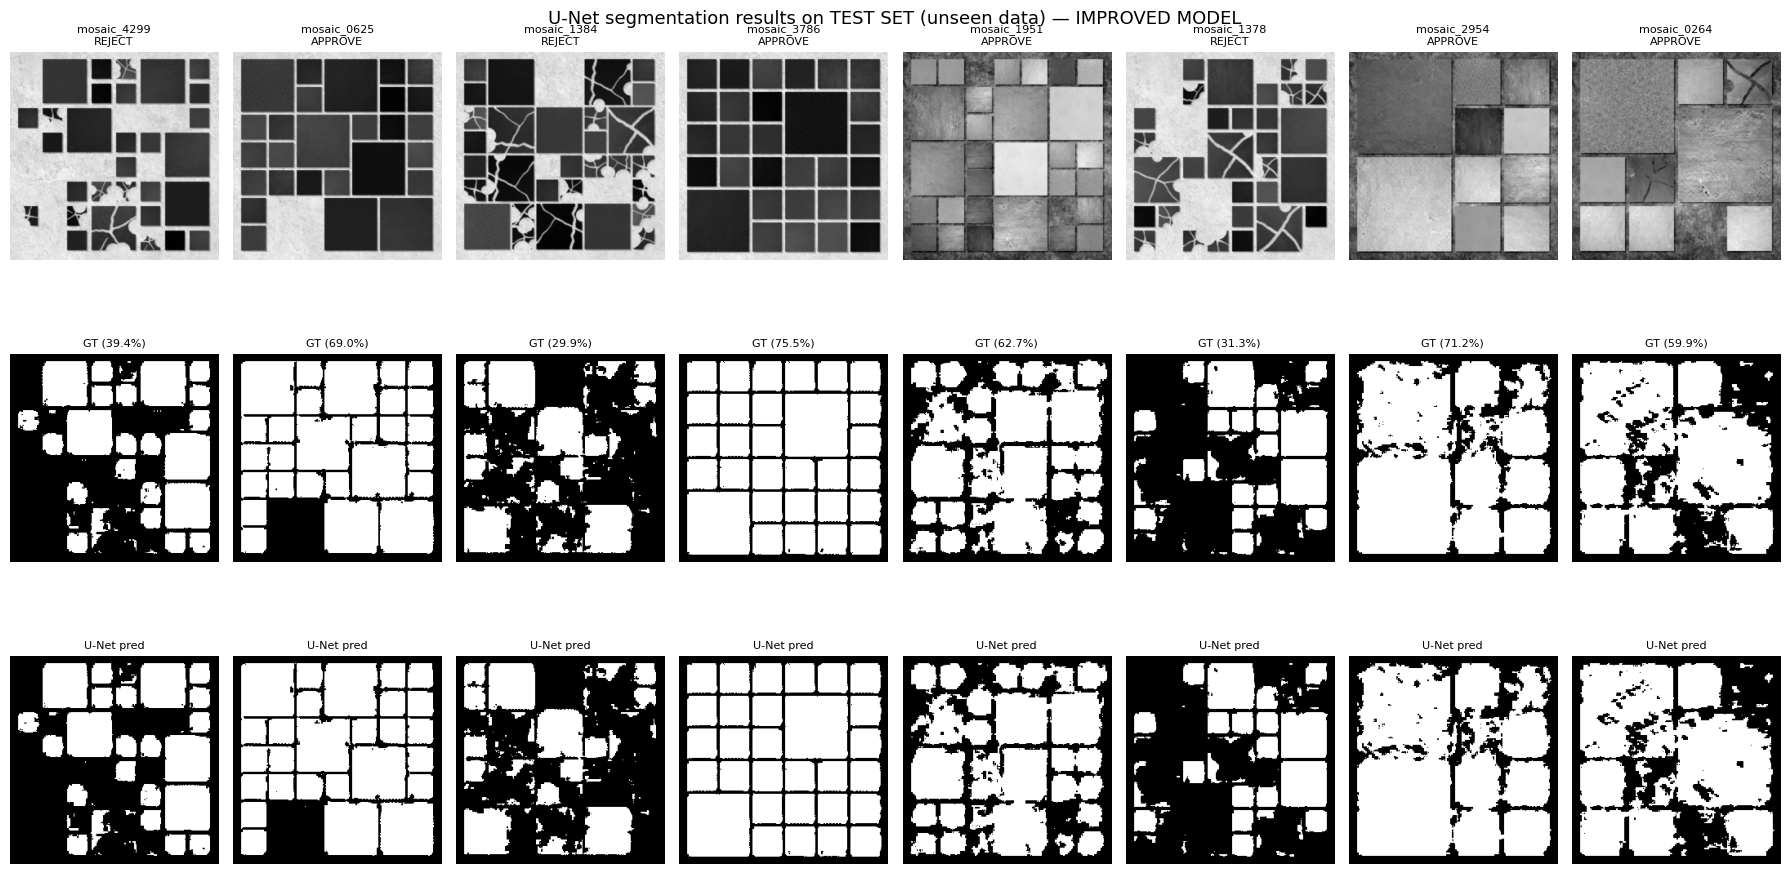

In [27]:
plot_segmentation_results(
    unet_improved, ds_full, ds_test, ground_truth,
    title="U-Net segmentation results on TEST SET (unseen data) — IMPROVED MODEL",
)


### 8.3 Improved FNN Classifier

Define your improved FNN classifier below. The input is the pooled latent vector from `unet_improved.get_latent()` — consider how to give the network more capacity.


In [32]:
class ImprovedFNN(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        # TODO: 🎯 define your improved FNN architecture here
        # Multi-layer MLP with dropout for better capacity and regularization
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(inplace=True),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, z):
        """Args: z — (B, latent_dim) pooled vector. Returns: (B,) probabilities."""
        return self.net(z).squeeze(-1)

Instantiate and train the improved FNN classifier.


In [33]:
classifier_fnn_improved = ImprovedFNN(latent_dim=unet_improved.latent_dim)
fnn_history = train_classifier_improved(
    unet_improved, classifier_fnn_improved, dl_train, dl_val,
    mode="fnn", epochs=50, lr=1e-3
)


[FNN] Epoch   0/50 | Train: 0.6162 | Val: 0.5057 | Acc: 67.3%
[FNN] Epoch   5/50 | Train: 0.2355 | Val: 0.2958 | Acc: 86.5%
[FNN] Epoch  10/50 | Train: 0.2293 | Val: 0.1668 | Acc: 93.6%
[FNN] Epoch  15/50 | Train: 0.2064 | Val: 0.1624 | Acc: 93.7%
[FNN] Epoch  20/50 | Train: 0.2081 | Val: 0.1513 | Acc: 94.4%
[FNN] Epoch  25/50 | Train: 0.2153 | Val: 0.1583 | Acc: 93.9%
[FNN] Epoch  30/50 | Train: 0.2017 | Val: 0.2021 | Acc: 91.5%
[FNN] Epoch  35/50 | Train: 0.1872 | Val: 0.1917 | Acc: 89.9%
[FNN] Epoch  40/50 | Train: 0.1926 | Val: 0.1560 | Acc: 92.8%
[FNN] Epoch  45/50 | Train: 0.1786 | Val: 0.1705 | Acc: 91.7%
[FNN] Epoch  49/50 | Train: 0.2001 | Val: 0.1497 | Acc: 94.3%


Plot FNN training curves.


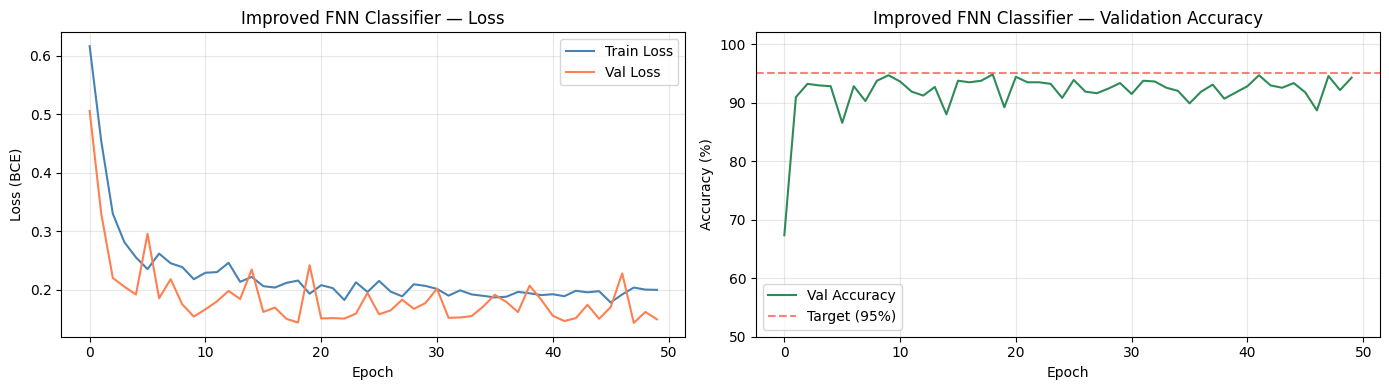

In [34]:
plot_classifier_history(fnn_history, title="Improved FNN Classifier")


### 8.4 Improved CNN Classifier

Define your improved CNN classifier below. The input is the spatial bottleneck map from `unet_improved.get_latent_map()` — think about what spatial processing layers could help.


In [37]:
class ImprovedCNN(nn.Module):
    def __init__(self, in_channels=64):
        super().__init__()
        # TODO: 🎯 define your improved CNN architecture here
        # Multi-layer conv feature extractor + global pooling + MLP head
        self.features = nn.Sequential(
            # Block 1: Expand channels, preserve spatial dims
            nn.Conv2d(in_channels, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.25),

            # Block 2: Downsample slightly for larger receptive field
            nn.Conv2d(128, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(64, 32),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, z_map):
        """Args: z_map — (B, in_channels, H', W') spatial map. Returns: (B,) probabilities."""
        x = self.features(z_map)
        return self.classifier(x).squeeze(-1)

Instantiate and train the improved CNN classifier.


In [38]:
classifier_cnn_improved = ImprovedCNN(in_channels=unet_improved.latent_dim)
cnn_history = train_classifier_improved(
    unet_improved, classifier_cnn_improved, dl_train, dl_val,
    mode="cnn", epochs=50, lr=1e-3
)


[CNN] Epoch   0/50 | Train: 0.4587 | Val: 0.3360 | Acc: 82.9%
[CNN] Epoch   5/50 | Train: 0.2057 | Val: 0.1254 | Acc: 95.5%
[CNN] Epoch  10/50 | Train: 0.1841 | Val: 0.1657 | Acc: 91.6%
[CNN] Epoch  15/50 | Train: 0.1903 | Val: 0.1046 | Acc: 96.1%
[CNN] Epoch  20/50 | Train: 0.1831 | Val: 0.1271 | Acc: 94.4%
[CNN] Epoch  25/50 | Train: 0.1813 | Val: 0.1064 | Acc: 95.9%
[CNN] Epoch  30/50 | Train: 0.1491 | Val: 0.1048 | Acc: 95.9%
[CNN] Epoch  35/50 | Train: 0.1533 | Val: 0.1094 | Acc: 95.3%
[CNN] Epoch  40/50 | Train: 0.1635 | Val: 0.0963 | Acc: 96.1%
[CNN] Epoch  45/50 | Train: 0.1622 | Val: 0.0912 | Acc: 96.5%
[CNN] Epoch  49/50 | Train: 0.1429 | Val: 0.1229 | Acc: 94.7%


Plot CNN training curves.


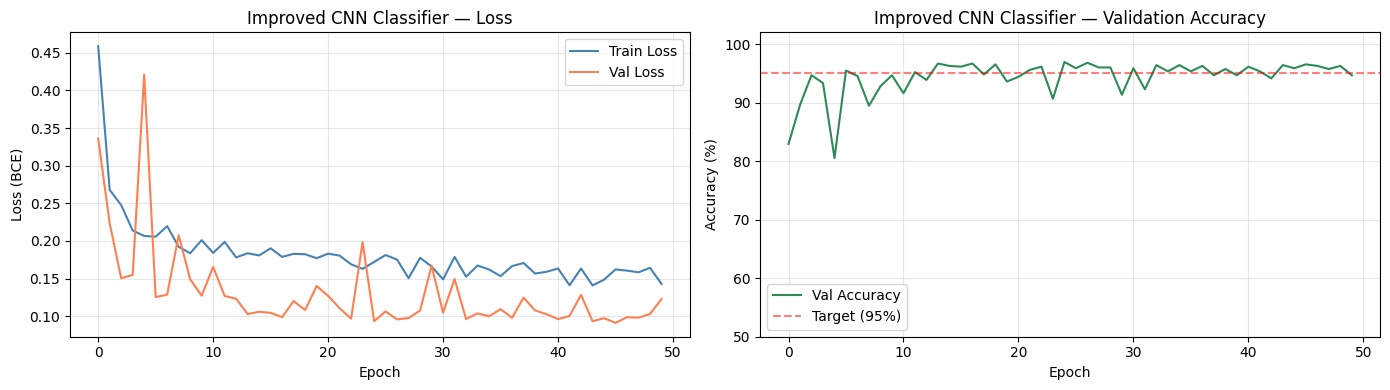

In [39]:
plot_classifier_history(cnn_history, title="Improved CNN Classifier")


### 8.5 Final Evaluation — Improved Models


In [40]:
df_improved, acc_improved = evaluate_models(
    unet_improved, classifier_fnn_improved, classifier_cnn_improved,
    ds_full, ds_test, ground_truth,
    model_label="IMPROVED MODELS"
)

print("\nFirst 20 predictions:")
df_improved.head(20).set_index("Image")



IMPROVED MODELS — Evaluating on 750 test samples (unseen during training)
  Threshold (40% coverage): 97.1% (728/750 correct)
  FNN classifier:           93.3% (700/750 correct)
  CNN classifier:           95.2% (714/750 correct)

First 20 predictions:


,Coverage,Actual,Threshold,FNN pred,CNN pred
Image,,,,,
mosaic_4299,39.4%,REJECT,REJECT,REJECT,REJECT
mosaic_0625,69.0%,APPROVE,APPROVE,APPROVE,APPROVE
mosaic_1384,29.9%,REJECT,REJECT,REJECT,REJECT
mosaic_3786,75.5%,APPROVE,APPROVE,APPROVE,APPROVE
mosaic_1951,62.7%,APPROVE,APPROVE,APPROVE,APPROVE
mosaic_1378,31.3%,REJECT,REJECT,REJECT,REJECT
mosaic_2954,71.2%,APPROVE,APPROVE,APPROVE,APPROVE
mosaic_0264,59.9%,APPROVE,APPROVE,APPROVE,APPROVE
mosaic_1266,29.8%,REJECT,REJECT,REJECT,REJECT


Plot accuracy comparison.


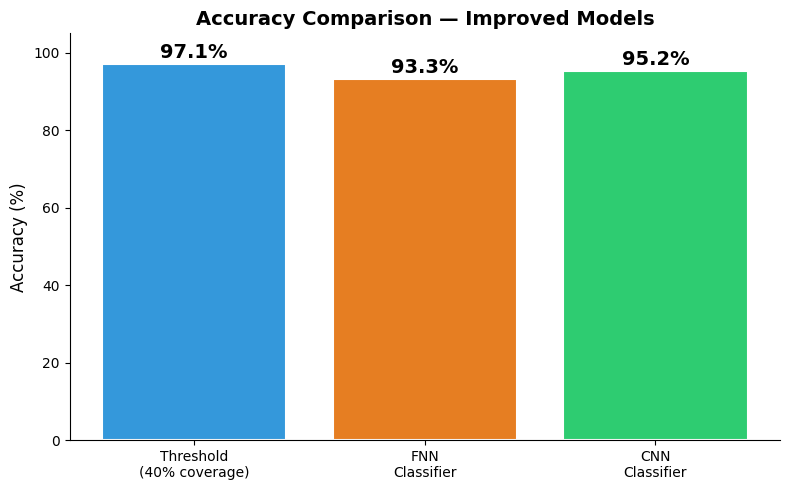

In [41]:
plot_accuracy_comparison(acc_improved, title="Accuracy Comparison — Improved Models")


### 8.6 Side-by-Side Comparison: Basic vs Improved


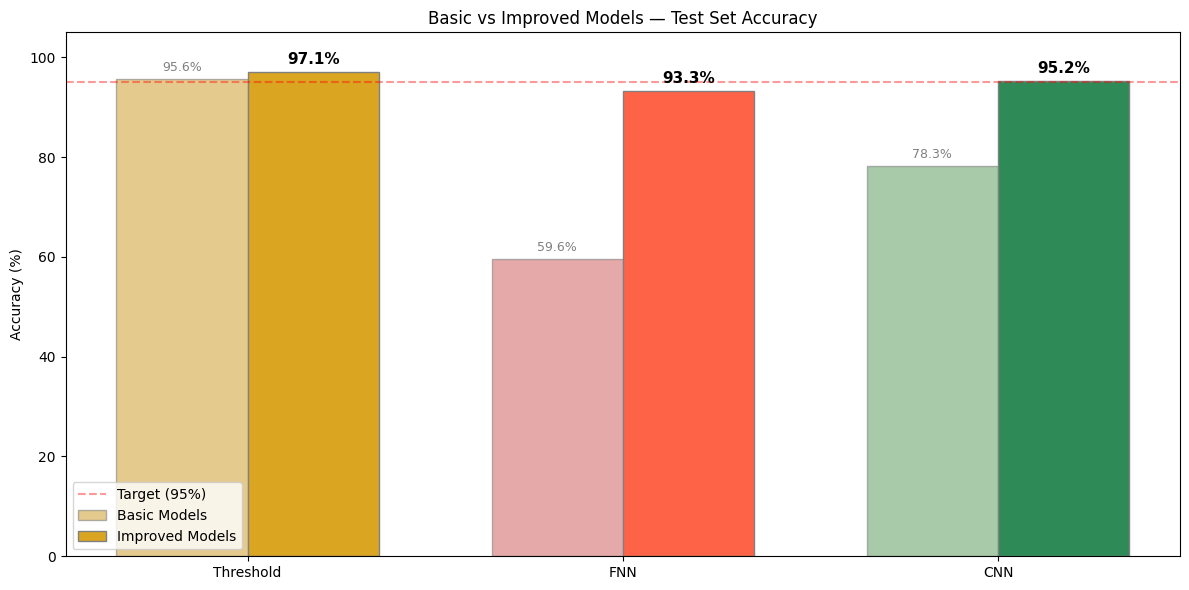


  IMPROVEMENT SUMMARY
  Threshold   :  95.6% ->  97.1%  (+1.5% change)
  FNN         :  59.6% ->  93.3%  (+33.7% change)
  CNN         :  78.3% ->  95.2%  (+16.9% change)


In [42]:
plot_comparison_basic_vs_improved(acc_basic, acc_improved)


### 8.7 Improved Pipeline Inference on a Single Image


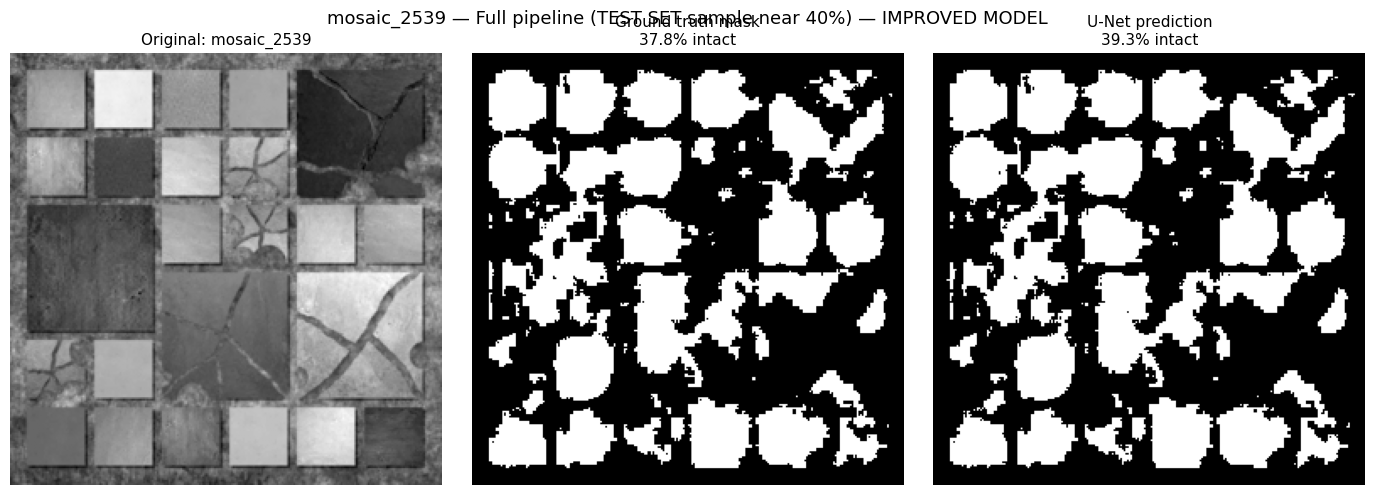

INFERENCE SUMMARY — IMPROVED MODEL (TEST SET SAMPLE)
Batch:                mosaic_2539
Actual coverage:      37.8%
Actual decision:      REJECT
------------------------------------------------------------
U-Net coverage:       39.3%
Threshold decision:   REJECT  (>40% → APPROVE)
FNN decision:         REJECT  (prob=0.207)
CNN decision:         REJECT  (prob=0.329)


In [44]:
import torch

# Reuse the same threshold sample from Section 7
img, gt_mask, label = ds_full[IDX]
unet_improved_device = next(unet_improved.parameters()).device # Define device here
img_t = img.unsqueeze(0).to(unet_improved_device)

unet_improved.eval(); classifier_fnn_improved.eval(); classifier_cnn_improved.eval()

with torch.no_grad():
    logits   = unet_improved(img_t)
    seg_pred = torch.sigmoid(logits)
    seg_bin  = (seg_pred > 0.5).float()
    coverage = seg_pred.mean().item()
    threshold_decision = "APPROVE" if coverage > 0.4 else "REJECT"

    z        = unet_improved.get_latent(img_t)
    fnn_prob = classifier_fnn_improved(z).item()
    fnn_decision = "APPROVE" if fnn_prob > 0.5 else "REJECT"

    z_map    = unet_improved.get_latent_map(img_t)
    cnn_prob = classifier_cnn_improved(z_map).item()
    cnn_decision = "APPROVE" if cnn_prob > 0.5 else "REJECT"

actual_decision  = "APPROVE" if label == 1 else "REJECT"
actual_coverage  = ground_truth.iloc[IDX]["coverage_pct"]

plot_inference_result(img, gt_mask, seg_bin, IDX, coverage, actual_coverage,
                      title_suffix="IMPROVED MODEL")

print("=" * 60)
print("INFERENCE SUMMARY — IMPROVED MODEL (TEST SET SAMPLE)")
print("=" * 60)
print(f"Batch:                mosaic_{IDX+1:04d}")
print(f"Actual coverage:      {actual_coverage*100:.1f}%")
print(f"Actual decision:      {actual_decision}")
print("-" * 60)
print(f"U-Net coverage:       {coverage*100:.1f}%")
print(f"Threshold decision:   {threshold_decision}  (>40% → APPROVE)")
print(f"FNN decision:         {fnn_decision}  (prob={fnn_prob:.3f})")
print(f"CNN decision:         {cnn_decision}  (prob={cnn_prob:.3f})")
print("=" * 60)

---
## 8b 🌐 Interactive Web App — Try Your Trained Model Live

In [45]:
import os
import numpy as np
from PIL import Image
import pandas as pd

APP_DATA_ROOT = "week2/project1/dataset"
ORIG_DIR = os.path.join(APP_DATA_ROOT, "original")
SEG_DIR  = os.path.join(APP_DATA_ROOT, "segmented")
os.makedirs(SEG_DIR, exist_ok=True)

model_for_app = unet_improved
model_for_app.eval()
_device    = next(model_for_app.parameters()).device
_transform = T.Compose([T.Resize((256, 256)), T.ToTensor()])

records   = []
filenames = sorted(f for f in os.listdir(ORIG_DIR) if f.lower().endswith(".jpg"))
print(f"Running inference on {len(filenames)} images...")

for i, fname in enumerate(filenames):
    img_pil   = Image.open(os.path.join(ORIG_DIR, fname)).convert("L")
    orig_size = img_pil.size
    img_t     = _transform(img_pil).unsqueeze(0).to(_device)

    with torch.no_grad():
        pred = torch.sigmoid(model_for_app(img_t)).squeeze().cpu().numpy()

    binary_mask   = (pred > 0.5).astype(np.uint8)
    coverage_pct  = float(binary_mask.mean())
    status        = "APPROVE" if coverage_pct >= 0.40 else "REJECT"

    stem = os.path.splitext(fname)[0]
    Image.fromarray(binary_mask * 255).convert("RGB") \
         .resize(orig_size, Image.Resampling.NEAREST) \
         .save(os.path.join(SEG_DIR, f"{stem}-segmented.jpg"))

    records.append({
        "filename":      fname,
        "intact_pixels": int(binary_mask.sum()),
        "coverage_pct":  round(coverage_pct, 4),
        "status":        status,
    })
    if (i + 1) % 500 == 0:
        print(f"  {i+1}/{len(filenames)}")

df_app = pd.DataFrame(records)
df_app.to_csv(os.path.join(APP_DATA_ROOT, "ground_truth.csv"), index=False)
approved = (df_app["status"] == "APPROVE").sum()
print(f"Done: {len(records)} images  →  APPROVE {approved}  |  REJECT {len(records) - approved}")

Running inference on 5000 images...
  500/5000
  1000/5000
  1500/5000
  2000/5000
  2500/5000
  3000/5000
  3500/5000
  4000/5000
  4500/5000
  5000/5000
Done: 5000 images  →  APPROVE 2820  |  REJECT 2180


In [46]:
import base64, json, os
import IPython.display
from google.colab import output

_df   = pd.read_csv(os.path.join(APP_DATA_ROOT, "ground_truth.csv"))
_tiles = [
    {
        "index":        int(i),
        "filename":     row["filename"],
        "coverage_pct": float(row["coverage_pct"]),
        "status":       row["status"],
    }
    for i, row in _df.iterrows()
]

def getTiles():
    return json.dumps(_tiles)

def getImage(filename, image_type):
    if image_type == "original":
        path = os.path.join(ORIG_DIR, filename)
    else:
        stem = os.path.splitext(filename)[0]
        path = os.path.join(SEG_DIR, f"{stem}-segmented.jpg")
    with open(path, "rb") as f:
        b64 = base64.b64encode(f.read()).decode("utf-8")
    return json.dumps({"image": b64})

output.register_callback("getTiles",  getTiles)
output.register_callback("getImage",  getImage)
print("Callbacks registered.")

with open("week2/project1/warehouse_app_colab.html") as f:
    html_app = f.read()

IPython.display.display(IPython.display.HTML(html_app))

Callbacks registered.
